[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drbob-richardson/stat220/blob/main/Assignments/Stat_220_HW8.ipynb)

**Prooblem 1:** Rent prices are of high interest to many people right now. Being able to predict rent well is important. Load in a data set of rental prices in India using the following command.

pd.read_csv("https://richardson.byu.edu/220/rent.csv")

The variables are, in order: BHK - number of bedrooms, Rent - rental fees, Size - square feet of space, AreaType - carpet or super, City, Furnished Status - furnished or unfurnished, Preferred - type of renter sought, Bathrooms, and Who to Contact.

Rent is the target variable. All other variables can be used as predictors.

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

Part a. Determine what each variable is, numeric or categorical, and if they are categorical if they are binary or not.

BHK, Rent, Size, and bathrooms are all numeric. AreaType, City, Furnished Statuis, Preferred, and Who to COntact are all categorical. Furnished Status and Preferred are binary.

Part b. Plot the target variable, Rent. Does it look skewed right or symmetric?

In [4]:
df = pd.read_csv("https://richardson.byu.edu/220/rent.csv")

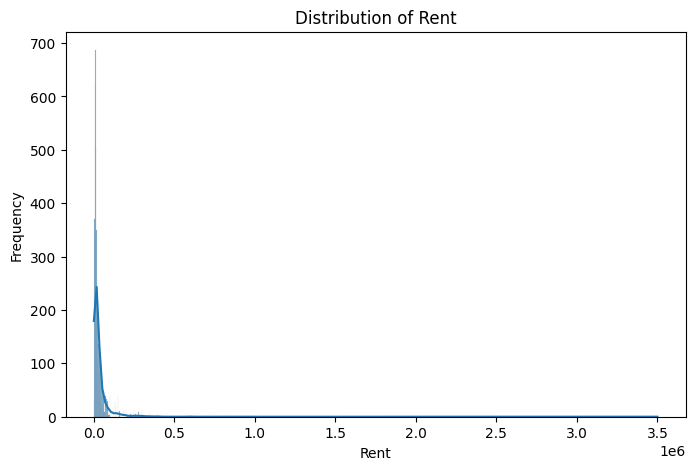

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Rent"], kde=True)
plt.title("Distribution of Rent")
plt.xlabel("Rent")
plt.ylabel("Frequency")
plt.show()

Part c. Fit a regression model with rent as the target and the other variables as predictors.

In [15]:
# Target
y = df["Rent"]

# Predictors = all other columns
X = df.drop(columns=["Rent"])

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Make sure everything is numeric
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Drop any rows with missing values
valid_rows = X.notna().all(axis=1) & y.notna()
X = X[valid_rows]
y = y[valid_rows]

# Add intercept
X = sm.add_constant(X)

# 🔑 Force everything to float so statsmodels can't complain
X = X.astype(float)
y = y.astype(float)

# Fit regression model
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     156.7
Date:                Sat, 22 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:01:20   Log-Likelihood:                -59261.
No. Observations:                4743   AIC:                         1.186e+05
Df Residuals:                    4728   BIC:                         1.186e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

Part d. Plot the fitted values versus the residuals. Does it look like it could use a log transformation.

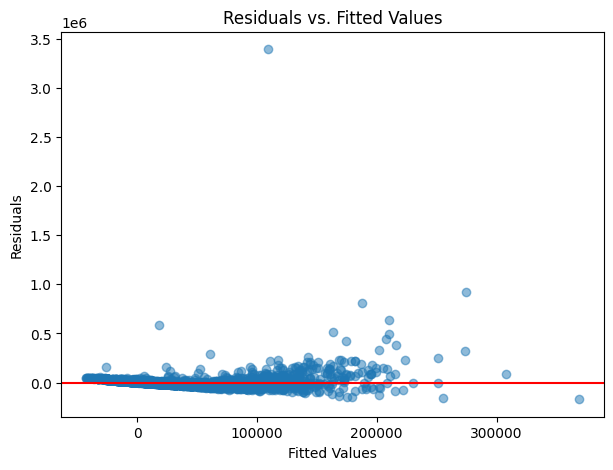

In [17]:
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(7,5))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color="red")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.show()

**Problem 2** Work with the log of rent.

Part a. Plot the log rent. Does it loook more or less symmetric?

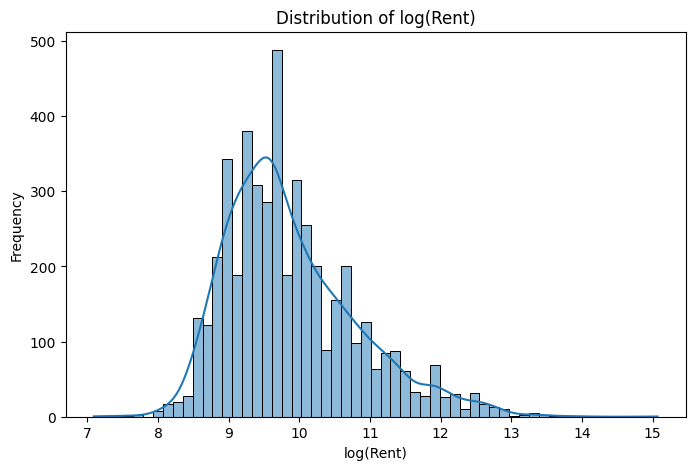

In [20]:
# Create log of rent
df["log_rent"] = np.log(df["Rent"])

plt.figure(figsize=(8,5))
sns.histplot(df["log_rent"], kde=True)
plt.title("Distribution of log(Rent)")
plt.xlabel("log(Rent)")
plt.ylabel("Frequency")
plt.show()

It looks more symetric.

Part b. Fit a regression model with log rent as the target and the other variables as predictors.

In [21]:
# Create log Rent
df["log_rent"] = np.log(df["Rent"])

# Target
y = df["log_rent"]

# Predictors
X = df.drop(columns=["Rent", "log_rent"])

# Dummy encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Ensure everything is numeric
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Drop missing rows
valid_rows = X.notna().all(axis=1) & y.notna()
X = X[valid_rows]
y = y[valid_rows]

# Add constant
X = sm.add_constant(X)

# Force numeric types
X = X.astype(float)
y = y.astype(float)

# Fit regression
model_log = sm.OLS(y, X).fit()

print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:               log_rent   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     1464.
Date:                Sat, 22 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:03:37   Log-Likelihood:                -2448.8
No. Observations:                4743   AIC:                             4928.
Df Residuals:                    4728   BIC:                             5025.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

Part c. Plot the fitted values versus residuals. Does this look any better?

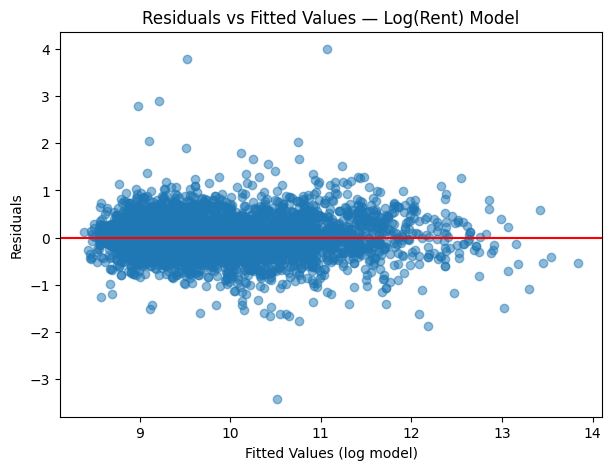

In [22]:
fitted_log = model_log.fittedvalues
residuals_log = model_log.resid

plt.figure(figsize=(7,5))
plt.scatter(fitted_log, residuals_log, alpha=0.5)
plt.axhline(0, color="red")
plt.xlabel("Fitted Values (log model)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values — Log(Rent) Model")
plt.show()

Part d. Use out of sample R^2 too determine which model is better.

In [25]:
# Create log rent
df["log_rent"] = np.log(df["Rent"])

# Target variables
y1 = df["Rent"]          # original rent model
y2 = df["log_rent"]      # log rent model

# Predictors
X = df.drop(columns=["Rent", "log_rent"])
X = pd.get_dummies(X, drop_first=True)

# Make numeric
X = X.apply(pd.to_numeric, errors="coerce")
y1 = pd.to_numeric(y1, errors="coerce")
y2 = pd.to_numeric(y2, errors="coerce")

# Drop rows with missing values
valid_rows = X.notna().all(axis=1) & y1.notna() & y2.notna()
X = X[valid_rows]
y1 = y1[valid_rows]
y2 = y2[valid_rows]

# Ensure all data passed to statsmodels is numeric (float)
X = X.astype(float)
y1 = y1.astype(float)
y2 = y2.astype(float)

# Train/test split
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X, y1, y2, test_size=0.3, random_state=42
)

# Add intercepts
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Fit models
model_rent = sm.OLS(y1_train, X_train_const).fit()
model_log  = sm.OLS(y2_train, X_train_const).fit()

# Predictions
pred_rent = model_rent.predict(X_test_const)
pred_log  = model_log.predict(X_test_const)

# Convert log predictions back to rent
pred_log_rentspace = np.exp(pred_log)

# Out-of-sample R²
r2_rent = r2_score(y1_test, pred_rent)
r2_log  = r2_score(y1_test, pred_log_rentspace)

r2_rent, r2_log

(0.48223785261080887, 0.6635129605138372)

the logarithmic model is better

**Problem 3** Check if predictors need a log transformation.

Part a. Fit another model where the predictor variable Size is given a log transformation as well as Rent.

In [57]:
df["log_rent"] = np.log(df["Rent"])
df["log_size"] = np.log(df["Size"])

y = df["log_rent"]

X = df.drop(columns=["Rent", "Size", "log_rent"])

X = pd.get_dummies(X, drop_first=True)

X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

valid_rows = X.notna().all(axis=1) & y.notna()
X = X[valid_rows]
y = y[valid_rows]

X = sm.add_constant(X)

X = X.astype(float)
y = y.astype(float)

model_log_both = sm.OLS(y, X).fit()

print(model_log_both.summary())

                            OLS Regression Results                            
Dep. Variable:               log_rent   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     1342.
Date:                Sat, 22 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:28:35   Log-Likelihood:                -2614.2
No. Observations:                4743   AIC:                             5258.
Df Residuals:                    4728   BIC:                             5355.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

Part b. Compare the p value Size in the model where Size is untransformed against the p value for log Size in the model with log Size. Is one or both significant.

In [56]:
# P-value for Size from model where Size is not logged
p_size = model_log.pvalues.filter(like="Size")
print("P-value for Size (untransformed):")
print(p_size)

# P-value for log_size from model where Size is logged
p_log_size = model_log_both.pvalues.filter(like="log_size")
print("\nP-value for log(Size):")
print(p_log_size)

P-value for Size (untransformed):
Size    4.983184e-105
dtype: float64

P-value for log(Size):
log_size    2.826692e-72
dtype: float64


Part c. Check out of sample R^2 in both models. Does taking the log of size improve the model?

In [55]:
df["log_rent"] = np.log(df["Rent"])
df["log_size"] = np.log(df["Size"])

X1 = df.drop(columns=["Rent", "log_rent", "log_size"])
y1 = df["log_rent"]

X1 = pd.get_dummies(X1, drop_first=True)
X1 = X1.apply(pd.to_numeric, errors="coerce")
y1 = pd.to_numeric(y1, errors="coerce")

valid = X1.notna().all(axis=1) & y1.notna()
X1 = X1[valid]
y1 = y1[valid]

X1 = X1.astype(float)
y1 = y1.astype(float)

X2 = df.drop(columns=["Rent", "Size", "log_rent"])
y2 = df["log_rent"]

X2 = pd.get_dummies(X2, drop_first=True)
X2 = X2.apply(pd.to_numeric, errors="coerce")
y2 = pd.to_numeric(y2, errors="coerce")

valid2 = X2.notna().all(axis=1) & y2.notna()
X2 = X2[valid2]
y2 = y2[valid2]

X2 = X2.astype(float)
y2 = y2.astype(float)

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)

X1_train_c = sm.add_constant(X1_train)
X1_test_c  = sm.add_constant(X1_test)

X2_train_c = sm.add_constant(X2_train)
X2_test_c  = sm.add_constant(X2_test)

m1 = sm.OLS(y1_train, X1_train_c).fit()    # model with Size
m2 = sm.OLS(y2_train, X2_train_c).fit()    # model with log(Size)

pred1 = m1.predict(X1_test_c)
pred2 = m2.predict(X2_test_c)

r2_m1 = r2_score(y1_test, pred1)
r2_m2 = r2_score(y2_test, pred2)

print("Out-of-Sample R² — Model with Size:", r2_m1)
print("Out-of-Sample R² — Model with log(Size):", r2_m2)

Out-of-Sample R² — Model with Size: 0.7992502238875965
Out-of-Sample R² — Model with log(Size): 0.7881445584795778


**Problem 4** Use the same Rent data to explore standardizing.

Part a. Use the data set with log Rent. Standardize the training data and fit a linear regression model.

In [54]:
df["log_rent"] = np.log(df["Rent"])

y = df["log_rent"]

X = df.drop(columns=["Rent", "log_rent"])

X = pd.get_dummies(X, drop_first=True)

X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

valid = X.notna().all(axis=1) & y.notna()
X = X[valid]
y = y[valid]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = sm.add_constant(X_train_scaled)
X_test_scaled  = sm.add_constant(X_test_scaled)

model_std = sm.OLS(y_train, X_train_scaled).fit()

print(model_std.summary())

                            OLS Regression Results                            
Dep. Variable:               log_rent   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     990.0
Date:                Sat, 22 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:27:27   Log-Likelihood:                -1644.5
No. Observations:                3320   AIC:                             3321.
Df Residuals:                    3304   BIC:                             3419.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.8792      0.007   1430.052      0.0

Part b. Check the p-values for the variables in this model against the model without standardization. Are there any differences?

In [53]:
print("P-values (Unstandardized Predictors):")
print(model_log.pvalues.head())   # show first few

print("\nP-values (Standardized Predictors):")
print(model_std.pvalues.head())

P-values (Unstandardized Predictors):
const                   0.000000e+00
BHK                     5.079590e-49
Size                   4.983184e-105
Bathroom                7.241551e-28
AreaType_Super Area     3.592620e-02
dtype: float64

P-values (Standardized Predictors):
const    0.000000e+00
x1       1.848549e-48
x2       1.445135e-57
x3       8.871972e-28
x4       8.512103e-01
dtype: float64


Yes the P-Values for the standard predictors were much larger

Part c. Use the standardization on the test set and make predictions for the model. Transform those predictions back to the original (log)scale.

In [52]:
log_predictions = model_std.predict(X_test_scaled)

rent_predictions = np.exp(log_predictions)
rent_predictions[:10]

array([54206.96910918, 10732.56161487, 13227.42442205,  6971.56706834,
        7609.95293721, 25988.23002345,  9250.62529974, 56839.99568593,
       33924.82960994,  7580.39736972])

**Problem 4**: The data set machine.csv can be loaded using the code

machine = pd.read_csv("https://richardson.byu.edu/220/machine.csv")

The target variable is the cost to maintain a certain type of energy production machinery. The predictors are weight of the machine, the attitude of the region the machine is located towards coal and oil refinery, the type of machine (front or back loading) and the industry the machine is in (coal or oil).

**Part a.** Build and tune a linear regression model to predict the target variable, Cost, using all the other variables besides car_name as predictors.  Tune the model so that only significant features remain.

In [37]:
# Load data
machine = pd.read_csv("https://richardson.byu.edu/220/machine.csv")

machine.head()

,Cost,Weight,Attitude,Type,Industry
0,6.068,16.60,Negative,Front,Oil
1,4.602,20.37,Negative,Front,Oil
2,3.282,20.37,Negative,Front,Oil
3,2.192,20.37,Negative,Back,Oil
4,2.572,20.37,Negative,Back,Oil


In [51]:
y = machine["Cost"]

X = machine.drop(columns=["Cost"])

X = pd.get_dummies(X, drop_first=True)

X = X.astype(float)
y = y.astype(float)

# Add intercept
X = sm.add_constant(X)

full_model = sm.OLS(y, X).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     188.3
Date:                Sat, 22 Nov 2025   Prob (F-statistic):           1.39e-78
Time:                        21:26:55   Log-Likelihood:                -871.71
No. Observations:                 289   AIC:                             1753.
Df Residuals:                     284   BIC:                             1772.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 5.1863      1.09

**Part b.** Plot the Cost of the machine against Weight. Distinguish the color of each. point based on the type of Industry. Repeat this to make plots for Cost against Weight with colors distinguished for attitude and machine type.

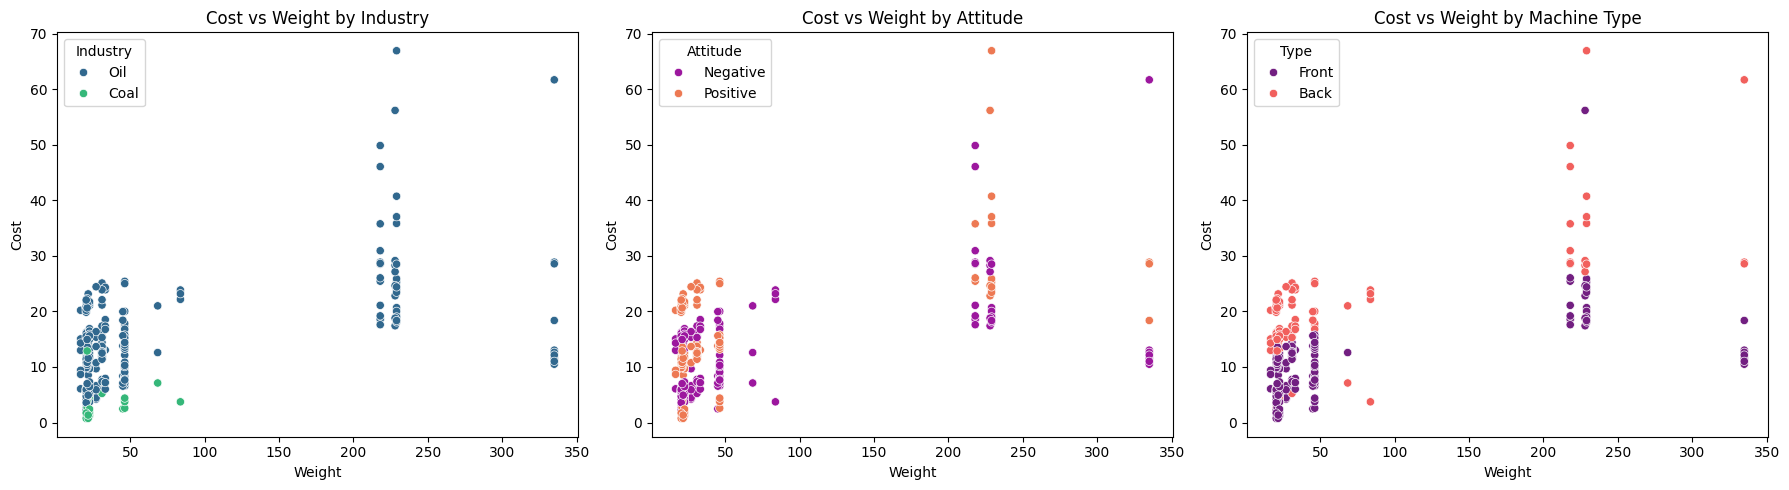

In [41]:
plt.figure(figsize=(18, 5))

# Plot 1: Cost vs Weight, colored by Industry
plt.subplot(1, 3, 1)
sns.scatterplot(data=machine, x="Weight", y="Cost", hue="Industry", palette="viridis")
plt.title("Cost vs Weight by Industry")
plt.xlabel("Weight")
plt.ylabel("Cost")

# Plot 2: Cost vs Weight, colored by Attitude
plt.subplot(1, 3, 2)
sns.scatterplot(data=machine, x="Weight", y="Cost", hue="Attitude", palette="plasma")
plt.title("Cost vs Weight by Attitude")
plt.xlabel("Weight")
plt.ylabel("Cost")

# Plot 3: Cost vs Weight, colored by Type
plt.subplot(1, 3, 3)
sns.scatterplot(data=machine, x="Weight", y="Cost", hue="Type", palette="magma")
plt.title("Cost vs Weight by Machine Type")
plt.xlabel("Weight")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

**Part c.** Try building a model with only Weight, Industry, and an interaction between Wieght and Industry as predictors. Interpret the meaning of the coefficients in this case.

In [50]:
y = machine["Cost"]

X_c = machine[["Weight", "Industry"]]
X_c = pd.get_dummies(X_c, drop_first=True)

X_c["Weight_x_Industry_Oil"] = X_c["Weight"] * X_c["Industry_Oil"]

X_c = sm.add_constant(X_c)

X_c = X_c.astype(float)
y = y.astype(float)

model_interaction = sm.OLS(y, X_c).fit()

print(model_interaction.summary())

print("\nInterpretation of Coefficients:")
print("---------------------------------")
print("The model is: Cost = b0 + b1*Weight + b2*Industry_Oil + b3*(Weight * Industry_Oil)")
print("Where Industry_Oil is 1 for Oil, 0 for Coal (baseline).")
print("\nFor Coal Industry (Industry_Oil = 0):")
print("  Cost = b0 + b1*Weight")
print(f"  Intercept for Coal: {model_interaction.params['const']:.3f}")
print(f"  Slope for Coal (Weight): {model_interaction.params['Weight']:.3f}")

print("\nFor Oil Industry (Industry_Oil = 1):")
print("  Cost = b0 + b1*Weight + b2*1 + b3*(Weight * 1)")
print("  Cost = (b0 + b2) + (b1 + b3)*Weight")
print(f"  Intercept for Oil: {model_interaction.params['const'] + model_interaction.params['Industry_Oil']:.3f}")
print(f"  Slope for Oil (Weight): {model_interaction.params['Weight'] + model_interaction.params['Weight_x_Industry_Oil']:.3f}")

                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     57.55
Date:                Sat, 22 Nov 2025   Prob (F-statistic):           4.10e-29
Time:                        21:26:35   Log-Likelihood:                -990.43
No. Observations:                 289   AIC:                             1989.
Df Residuals:                     285   BIC:                             2004.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     4.52

**Part d.** Plot the fitted regression lines for the model in Part c on top of the plot between Weight and Cost, with the data colored according to Industry.

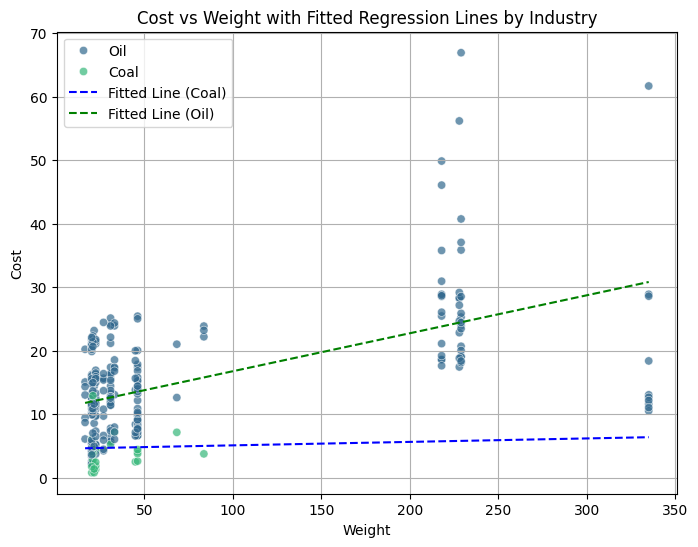

In [49]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=machine, x="Weight", y="Cost", hue="Industry", palette="viridis", alpha=0.7)
plt.title("Cost vs Weight with Fitted Regression Lines by Industry")
plt.xlabel("Weight")
plt.ylabel("Cost")

b0 = model_interaction.params['const']
b1 = model_interaction.params['Weight']
b2 = model_interaction.params['Industry_Oil']
b3 = model_interaction.params['Weight_x_Industry_Oil']

min_weight = machine['Weight'].min()
max_weight = machine['Weight'].max()
weight_range = np.linspace(min_weight, max_weight, 100)

fitted_coal = b0 + b1 * weight_range
plt.plot(weight_range, fitted_coal, color='blue', linestyle='--', label='Fitted Line (Coal)')

fitted_oil = (b0 + b2) + (b1 + b3) * weight_range
plt.plot(weight_range, fitted_oil, color='green', linestyle='--', label='Fitted Line (Oil)')

plt.legend()
plt.grid(True)
plt.show()

**Problem 5.**

**Part a.** For the model created in Problem 4a, using all the variables in the model tuned to significant features, report the out of sample R^2 value.

In [48]:
machine = pd.read_csv("https://richardson.byu.edu/220/machine.csv")

y_p4a = machine["Cost"]

X_p4a = machine.drop(columns=["Cost"])

X_p4a = pd.get_dummies(X_p4a, drop_first=True)

X_p4a = X_p4a.astype(float)
y_p4a = y_p4a.astype(float)

X_train_p4a, X_test_p4a, y_train_p4a, y_test_p4a = train_test_split(
    X_p4a, y_p4a, test_size=0.3, random_state=42
)

X_train_p4a_const = sm.add_constant(X_train_p4a)
X_test_p4a_const = sm.add_constant(X_test_p4a)

model_p4a = sm.OLS(y_train_p4a, X_train_p4a_const).fit()

y_pred_p4a = model_p4a.predict(X_test_p4a_const)

r2_out_of_sample_p4a = r2_score(y_test_p4a, y_pred_p4a)

print(f"Out-of-sample R-squared for Problem 4a model: {r2_out_of_sample_p4a:.3f}")

Out-of-sample R-squared for Problem 4a model: 0.735


**Part b**. Start with a model with all the predictors. Add in Weight^2 and interactions between weight and each other predictor. Tune the model to keep only significant features. Report the out of sample R^2 for this model.

In [46]:
machine = pd.read_csv("https://richardson.byu.edu/220/machine.csv")

y = machine["Cost"]

X = machine.drop(columns=["Cost"])

X["Weight_sq"] = X["Weight"]**2

X = pd.get_dummies(X, drop_first=True)

X["Weight_x_Attitude_Positive"] = X["Weight"] * X["Attitude_Positive"]
X["Weight_x_Type_Front"]      = X["Weight"] * X["Type_Front"]
X["Weight_x_Industry_Oil"]    = X["Weight"] * X["Industry_Oil"]

X = X.astype(float)
y = y.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

full_model_p5b = sm.OLS(y_train, X_train_const).fit()
print("\n--- Full Model (Problem 5b) Summary ---")
print(full_model_p5b.summary())

def backward_elimination(X_data, y_data, threshold=0.05):
    features = list(X_data.columns)
    while True:
        model = sm.OLS(y_data, sm.add_constant(X_data[features])).fit()
        p_values = model.pvalues.drop('const') # Exclude constant's p-value
        max_p_value = p_values.max()

        if max_p_value > threshold:
            non_significant_feature = p_values.idxmax()
            features.remove(non_significant_feature)
            print(f"Removing non-significant feature: {non_significant_feature} (p={max_p_value:.3f})")
        else:
            break
    return features, model

print("\n--- Starting Backward Elimination for Problem 5b ---")
significant_features, tuned_model_p5b = backward_elimination(X_train, y_train)

print("\n--- Tuned Model (Problem 5b) Summary ---")
print(tuned_model_p5b.summary())

X_test_tuned = sm.add_constant(X_test[significant_features])
y_pred_p5b = tuned_model_p5b.predict(X_test_tuned)

r2_out_of_sample_p5b = r2_score(y_test, y_pred_p5b)

print(f"\nOut-of-sample R-squared for Tuned Problem 5b model: {r2_out_of_sample_p5b:.3f}")


--- Full Model (Problem 5b) Summary ---
                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     116.4
Date:                Sat, 22 Nov 2025   Prob (F-statistic):           1.26e-69
Time:                        21:25:26   Log-Likelihood:                -568.29
No. Observations:                 202   AIC:                             1155.
Df Residuals:                     193   BIC:                             1184.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------